# WP5 · 04 — Build C: lapse-rate–corrected temperature exposure

**Work package:** WP5 / MAUP–exposure sensitivity · plan `docs/maup_sensitivity_and_spatial_cv_plan.md` §3.1b
**Owner:** Geospatial Lead · **Country:** Sri Lanka · **Variables:** t2m, d2m, RH

## Read this before any number below: the plan's prior about Build C is inverted here

`wp5_00` measured the elevation displacement on **ERA5-Land's 0.1° grid** and concluded that Build B
already captured ~92% of it, leaving Build C worth **≤0.36 °C** — the lowest-value rung of the
A→B→C ladder, whose "acceptance target should be set at a few tenths of a degree." The plan's
§7 sequencing follows that reading, and `notebooks_wp45/README.md` lists this notebook as blocked
behind a 0.1° rebuild.

**That reasoning does not survive the grid we were actually forced onto.** `wp5_02` had to build
Build B on **ERA5 0.25°** (no CDS key), where Build B captures only **65.3%** of the displacement.
The share Build C must recover is the complement of Build B's reach, so it *grows* as the grid
coarsens. Measured below, on the 0.25° grid:

| step | mean \|ΔT\| across the 26 districts, measured |
|---|---|
| A′ → B  (population weighting, `wp5_02`) | 0.205 °C |
| **B → C  (lapse correction, this notebook)** | **0.306 °C** |

**Build C is worth about half again as much as Build B here** — the rung the plan ranked last moves
district exposure ~1.5× as far as the rung it ranked first. It is also the one rung that partially
compensates for the missing 0.1° data rather than being degraded by its absence.

The physical reason is visible in one number. ERA5's own orography over Sri Lanka peaks at
**1,219 m**; the island reaches **2,524 m**. The reanalysis simply does not contain the central
highlands, so its 2 m temperature is issued for a mountain range roughly half the height of the real
one — and it is the highland districts whose populations sit nearest *Aedes*' lower thermal bound.

## The distinction this notebook must not blur

A→B and B→C are **not the same kind of effect**, and reporting them as one ladder without saying so
would overstate the MAUP result.

- **A→B is a re-weighting.** It moves weight between cells within a district; nationally it is close
  to mean-preserving. It is a pure areal-unit / exposure-construction effect — WP5's actual subject.
- **B→C is largely a level correction.** Measured below, **0.223 °C** of its 0.306 °C mean is ERA5's
  orography deficit — present under area weighting too — against **0.169 °C** of genuine sub-grid
  population placement. (The two are not simply additive: in Nuwara Eliya they oppose, −2.26 and
  +0.34 °C.) The clearest case is Nuwara Eliya itself, whose population-versus-area displacement is
  only **+0.15 °C** yet whose B→C shift is **−1.9 °C**: almost none of that is MAUP.

So §6 decomposes B→C into the part that is a reanalysis bias correction (present under *any*
weighting) and the part that is genuinely sub-grid population placement. Only the second belongs to
the MAUP argument; the first belongs to the exposure-quality argument, and both are worth having.

## What it builds

| arm | weights | lapse-corrected | what it is |
|---|---|---|---|
| `a_frac` | fractional area | no | the area-weighted arm (from `wp5_02`) |
| `b_pop` | population | no | **Build B** (from `wp5_02`) |
| `c_frac` | fractional area | **yes** | area-weighted counterpart — isolates the level correction |
| `c_pop` | population | **yes** | **Build C** |

**§10 and §11 test all of this against station observations** — six GHCN stations including Nuwara
Eliya at 1,880 m — rather than resting the highland magnitudes on the DEM and an assumed lapse rate.

No outcome data is touched, no linkage, no models.

## 1 · Setup

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio, rasterio.features
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
ERA5 = QUAR / "era5_0p25_window"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
SEED = prov0["seed"]
POP_YEAR = 2020                     # newest WorldPop UN-adj vintage staged; wp5_00 section 11

# ERA5 grid: values on multiples of 0.25 deg are cell CENTRES, so edges sit at +/- 0.125
G25 = dict(res=0.25, edge_lon=-180.125, edge_lat=90.125)
COL_OFFSET = 720                    # weight-field cell_col is indexed from -180

# Lapse rates. Temperature: the standard environmental rate, as plan section 3.1b specifies to
# "start with". Dewpoint: dewpoint falls with height far more slowly than temperature; section 8
# runs the two bracketing alternatives rather than asserting this one.
LAPSE_T  = 6.5 / 1000               # degC per metre
LAPSE_TD = 1.5 / 1000               # degC per metre

print("staged ERA5 files:", len(list(ERA5.glob("*.npz"))))
print("geometry exists  :", GEOM.exists())
print(f"lapse rates: T {1000*LAPSE_T:.1f} degC/km | Td {1000*LAPSE_TD:.1f} degC/km")

staged ERA5 files: 16
geometry exists  : True
lapse rates: T 6.5 degC/km | Td 1.5 degC/km


## 2 · Geometry, and the frame check

In [2]:
rdhs = gpd.read_file(GEOM)
sha16 = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
N_UNITS = len(rdhs)
assert sha16 == prov0["geometry_sha256_16"], "geometry differs from the M6 frame — stop"
print("units", N_UNITS, "| crs", rdhs.crs, "| sha", sha16, "OK")

units 26 | crs EPSG:4326 | sha 9e5e2c0a541ecac1 OK


## 3 · The new input: ERA5's own orography

Build C's whole content is the gap between the elevation ERA5 *thinks* a place has and the elevation
it actually has. The first of those is the model's surface geopotential — an invariant field, served
by ARCO-ERA5 in the same `raw/date-variable-single_level/` layout as `t2m` and `d2m`, so
`scripts/srilanka_era5_window_reader_v1.py` reads it unchanged and no CDS key is needed here either.

Correcting to a DEM without it would be the obvious error: subtracting the DEM's own cell mean
instead would silently assume ERA5 sits at the true mean elevation, which is exactly the assumption
that fails in the highlands.

Two properties are asserted rather than trusted — that the field really is invariant (it is served
with a 24-hour time axis and a date in the path, either of which could be real), and that it is
geopotential rather than geopotential height.

In [3]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
import requests
import srilanka_era5_window_reader_v1 as E

z0 = np.load(ERA5 / "era5_0p25_t2m_2018.npz")
I0, I1, J0, J1 = z0["window"]
era5_lat = 90.0 - 0.25 * np.arange(721)
era5_lon = 0.25 * np.arange(1440)
print("stored window: rows", I0, I1, "cols", J0, J1)
print(f"covers lat {era5_lat[I1]:.2f}..{era5_lat[I0]:.2f}  lon {era5_lon[J0]:.2f}..{era5_lon[J1]:.2f}")

s = requests.Session()
zg = E.read_window(s, E.BASE % (2018, 1, 1, "geopotential"), "z", I0, I1, J0, J1)
print("\ngeopotential window", zg.shape, "(hours, lat, lon)")

# (a) invariant within the day, and across five years
assert np.abs(zg - zg[0]).max() == 0.0, "surface geopotential varies within the day — not invariant"
zg2 = E.read_window(s, E.BASE % (2023, 6, 15, "geopotential"), "z", I0, I1, J0, J1)
assert np.abs(zg2[0] - zg[0]).max() == 0.0, "surface geopotential differs between dates"
print("invariant: 0.0 difference across 24 hours and across 2018 vs 2023")

# (b) geopotential (m2 s-2), not geopotential height (m) — divide by g
OROG = zg[0] / 9.80665
print(f"orography {OROG.min():.1f} .. {OROG.max():.1f} m over the window")
assert 800 < OROG.max() < 2000, "peak implausible for a 0.25 deg smoothing of Sri Lanka"

stored window: rows 320 337 cols 318 328
covers lat 5.75..10.00  lon 79.50..82.00



geopotential window (24, 18, 11) (hours, lat, lon)


invariant: 0.0 difference across 24 hours and across 2018 vs 2023
orography -34.4 .. 1219.3 m over the window


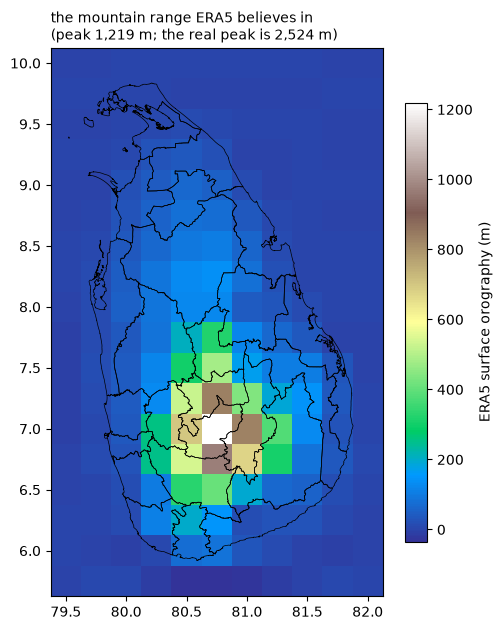

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 6.4))
im = ax.imshow(OROG, cmap="terrain",
               extent=[era5_lon[J0] - .125, era5_lon[J1] + .125,
                       era5_lat[I1] - .125, era5_lat[I0] + .125])
rdhs.boundary.plot(ax=ax, color="k", lw=.5)
plt.colorbar(im, ax=ax, label="ERA5 surface orography (m)", shrink=.8)
ax.set_title("the mountain range ERA5 believes in\n(peak 1,219 m; the real peak is 2,524 m)",
             loc="left", fontsize=10)
plt.tight_layout()

## 4 · The elevation people actually live at, per (district, ERA5 cell)

The second elevation is the Copernicus GLO-30 DEM, resampled onto the WorldPop 100 m grid exactly as
`wp5_00` §did — same tiles, same `Resampling.average`, so this notebook's elevations are the ones
whose district aggregates `wp5_00` already published.

The new quantity is the **per-pair** mean: for each (district, 0.25° cell) pair, the mean DEM
elevation of the 100 m pixels in that intersection, weighted by population and (separately) by area.
`wp5_00` computed only the area-weighted version, and only to report a between/within split.

In [5]:
with rasterio.open(M6 / "worldpop" / f"lka_ppp_{POP_YEAR}_UNadj.tif") as src:
    pop = src.read(1).astype(np.float64)
    T, (H, W), NODATA = src.transform, src.shape, src.nodata
pop[pop == NODATA] = 0.0

lon_c = T.c + (np.arange(W) + 0.5) * T.a
lat_c = T.f + (np.arange(H) + 0.5) * T.e

dist = rasterio.features.rasterize([(g, i + 1) for i, g in enumerate(rdhs.geometry)],
                                   out_shape=(H, W), transform=T, fill=0, dtype="int32")
inside = dist > 0
coslat = np.broadcast_to(np.cos(np.deg2rad(lat_c))[:, None], (H, W))

d_in, p_in, a_in = dist[inside], pop[inside], coslat[inside]
LON = np.broadcast_to(lon_c[None, :], (H, W))[inside]
LAT = np.broadcast_to(lat_c[:, None], (H, W))[inside]

print(f"WorldPop {POP_YEAR}: {H} x {W} @ {T.a:.6f} deg")
print(f"pixels inside districts {inside.sum():,} | population captured {p_in.sum()/1e6:.3f} M "
      f"({100*p_in.sum()/pop.sum():.2f}%)")

WorldPop 2020: 4700 x 2676 @ 0.000833 deg
pixels inside districts 7,793,861 | population captured 21.121 M (98.63%)


In [6]:
srcs = [rasterio.open(p) for p in sorted((M6 / "dem").glob("*.tif"))]
mos, mos_T = merge(srcs)
elev = np.zeros((H, W), dtype=np.float32)
reproject(mos[0], elev, src_transform=mos_T, src_crs=srcs[0].crs,
          dst_transform=T, dst_crs="EPSG:4326", resampling=Resampling.average)
for src_ in srcs:
    src_.close()
del mos

e_in = elev[inside].astype(np.float64)
print(f"DEM on the WorldPop grid: {e_in.min():.0f} .. {e_in.max():.0f} m")
print(f"island max {e_in.max():.0f} m vs Pidurutalagala 2,524 m (notebook 01 cross-check)")

DEM on the WorldPop grid: -5 .. 2515 m
island max 2515 m vs Pidurutalagala 2,524 m (notebook 01 cross-check)


In [7]:
# Cell (row, col) on grid `g` — wp5_00 section 3, unchanged.
def cell_ij(lon, lat, g):
    ci = np.floor((lon - g["edge_lon"]) / g["res"]).astype(np.int32)
    ri = np.floor((g["edge_lat"] - lat) / g["res"]).astype(np.int32)
    return ri, ci

ri, ci = cell_ij(LON, LAT, G25)
key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
uniq, inv = np.unique(key, return_inverse=True)

pair = pd.DataFrame({
    "unit":     (uniq // 10**10).astype(int),
    "cell_row": ((uniq % 10**10) // 10**5).astype(int),
    "cell_col": (uniq % 10**5).astype(int),
    "pop_sum":  np.bincount(inv, weights=p_in),
    "area":     np.bincount(inv, weights=a_in),
    "z_pop":    np.bincount(inv, weights=e_in * p_in) / np.bincount(inv, weights=p_in),
    "z_area":   np.bincount(inv, weights=e_in * a_in) / np.bincount(inv, weights=a_in),
})
pair["rdhs_name"]   = rdhs.rdhs_name.values[pair.unit - 1]
pair["geometry_id"] = rdhs.geometry_id.values[pair.unit - 1]
pair["w_area"] = pair.area    / pair.groupby("unit").area.transform("sum")
pair["w_pop"]  = pair.pop_sum / pair.groupby("unit").pop_sum.transform("sum")

assert np.allclose(pair.groupby("unit").w_area.sum(), 1.0)
assert np.allclose(pair.groupby("unit").w_pop.sum(), 1.0)
assert pair.z_pop.notna().all() and pair.z_area.notna().all()
print(f"(district, cell) pairs {len(pair)} | distinct cells "
      f"{pair.groupby(['cell_row','cell_col']).ngroups}")
print(f"per-pair elevation: z_pop {pair.z_pop.min():.0f}..{pair.z_pop.max():.0f} m | "
      f"z_area {pair.z_area.min():.0f}..{pair.z_area.max():.0f} m")

(district, cell) pairs 260 | distinct cells 117
per-pair elevation: z_pop 3..1473 m | z_area 2..1701 m


### 4.1 · The weight field must be the one `wp5_02` used

Build C is only interpretable as a single-axis step from Build B if the weights are byte-identical.
They are rebuilt here from the same inputs rather than read, so this asserts them against the frozen
file instead of assuming the rebuild agrees.

In [8]:
wfroz = pd.read_csv(QUAR / "wp5_buildB_weights_era5_0p25_srilanka_2020.csv")
k = ["unit", "cell_row", "cell_col"]
chk = wfroz[k + ["w_area", "w_pop"]].merge(pair[k + ["w_area", "w_pop"]], on=k,
                                           suffixes=("_frozen", "_here"), how="outer")
assert len(chk) == len(wfroz) == len(pair), "pair set differs from the frozen weight field"
assert np.allclose(chk.w_area_frozen, chk.w_area_here) and np.allclose(chk.w_pop_frozen, chk.w_pop_here)
print(f"weight field reproduced exactly: {len(chk)} pairs, max |diff| "
      f"{max(np.abs(chk.w_area_frozen-chk.w_area_here).max(), np.abs(chk.w_pop_frozen-chk.w_pop_here).max()):.2e}")

# index into the staged ERA5 window
pair["i"] = pair.cell_row - I0
pair["j"] = pair.cell_col - COL_OFFSET - J0
assert pair.i.between(0, I1 - I0).all() and pair.j.between(0, J1 - J0).all()
pair["z_orog"] = OROG[pair.i.values, pair.j.values]
print("orography joined to every pair:", f"{pair.z_orog.min():.0f}..{pair.z_orog.max():.0f} m")

weight field reproduced exactly: 260 pairs, max |diff| 9.82e-17
orography joined to every pair: -5..1219 m


## 5 · Why "correct on the fine grid, before aggregation" costs nothing here

Plan §3.1b requires the lapse correction to be applied at the fine grid *before* aggregation, and
warns against correcting the aggregate. That warning is about a real failure mode — but for an affine
correction the two are **identical**, and proving it is what makes this notebook cheap.

For a 100 m pixel *p* inside (district *d*, cell *c*):

$$T_{\text{corr}}(p) = T_{\text{ERA5}}(c) - \Gamma\,\bigl(z_p - z_{\text{orog}}(c)\bigr)$$

Aggregating with per-pixel weights $\omega_p$ that sum to 1 within the district, and writing
$w_c=\sum_{p\in c}\omega_p$ and $\bar z_c=\sum_{p\in c}\omega_p z_p / w_c$:

$$\sum_p \omega_p T_{\text{corr}}(p)
  = \sum_c w_c\Bigl[T_{\text{ERA5}}(c) - \Gamma\bigl(\bar z_c - z_{\text{orog}}(c)\bigr)\Bigr]$$

The right-hand side is a per-pair correction using only the **weighted mean elevation of the
intersection** — the `z_pop` / `z_area` columns built in §4. No 100 m temperature cube is ever
needed, and the result is exact, not an approximation.

**The exception is relative humidity**, which is not affine in $(T, T_d)$. RH must therefore be
recomputed from corrected $T$ and $T_d$ **per cell, per hour**, before averaging — the same rule
`wp5_02` §6 applied. That is done in §7, not by patching the Build B table.

**A consequence worth stating before it is measured:** the correction $-\Gamma(\bar z_c - z_{orog}(c))$
carries no time index. For `t2m` and `d2m`, Build C is therefore Build B plus a **constant per-district
offset**. §9 takes that seriously rather than treating it as a technicality.

## 6 · The correction field, and the decomposition the MAUP argument needs

$\Delta z$ per district is the population-weighted gap between real and believed elevation. Splitting
it is what keeps §0's promise:

- $\Delta z_{\text{area}} = \sum_c w^{\text{area}}_c(\bar z^{\text{area}}_c - z_{\text{orog}}(c))$ —
  the **orography deficit**: present under any weighting, a reanalysis-quality correction.
- $\Delta z_{\text{pop}} - \Delta z_{\text{area}}$ — the **sub-grid population placement**: the part
  that exists only because people are not spread uniformly inside a cell. *This* is the MAUP part.

In [9]:
dz = pair.groupby("rdhs_name").apply(lambda d: pd.Series({
    "dz_pop":  np.average(d.z_pop  - d.z_orog, weights=d.w_pop),
    "dz_area": np.average(d.z_area - d.z_orog, weights=d.w_area),
}), include_groups=False).reset_index()

dz["dT_c_pop"]   = -LAPSE_T * dz.dz_pop            # B -> C, population weighted
dz["dT_c_area"]  = -LAPSE_T * dz.dz_area           # the same correction under area weighting
dz["dT_orog"]    = dz.dT_c_area                    # reanalysis bias part
dz["dT_subgrid"] = dz.dT_c_pop - dz.dT_c_area      # MAUP part
dz = dz.sort_values("dT_c_pop")

print("Build B -> Build C temperature shift, decomposed (degC):\n")
print(dz[["rdhs_name", "dz_pop", "dz_area", "dT_c_pop", "dT_orog", "dT_subgrid"]]
      .round(3).to_string(index=False))
print(f"\nmean |B->C|        {dz.dT_c_pop.abs().mean():.3f} degC   "
      f"(A'->B was 0.205 degC, wp5_02)")
print(f"  of which orography deficit  {dz.dT_orog.abs().mean():.3f} degC")
print(f"  of which sub-grid placement {dz.dT_subgrid.abs().mean():.3f} degC")
print(f"largest: {dz.iloc[0].rdhs_name} {dz.iloc[0].dT_c_pop:+.2f} degC")

Build B -> Build C temperature shift, decomposed (degC):

   rdhs_name   dz_pop  dz_area  dT_c_pop  dT_orog  dT_subgrid
Nuwara Eliya  294.954  347.122    -1.917   -2.256       0.339
     Badulla  205.124   79.817    -1.333   -0.519      -0.814
      Matale   32.677   43.995    -0.212   -0.286       0.074
    Vavuniya    6.806    8.992    -0.044   -0.058       0.014
      Jaffna    5.165    2.072    -0.034   -0.013      -0.020
Killinochchi   -1.193   -3.316     0.008    0.022      -0.014
  Mullaitivu   -1.970    3.487     0.013   -0.023       0.035
Anuradhapura   -3.834    4.322     0.025   -0.028       0.053
    Puttalam   -7.435   -3.756     0.048    0.024       0.024
 Trincomalee   -9.523   -6.802     0.062    0.044       0.018
      Mannar   -9.546   -3.551     0.062    0.023       0.039
  Batticaloa  -10.698  -12.079     0.070    0.079      -0.009
 Polonnaruwa  -11.555  -11.780     0.075    0.077      -0.001
  Hambantota  -17.572   -9.921     0.114    0.064       0.050
       Galle

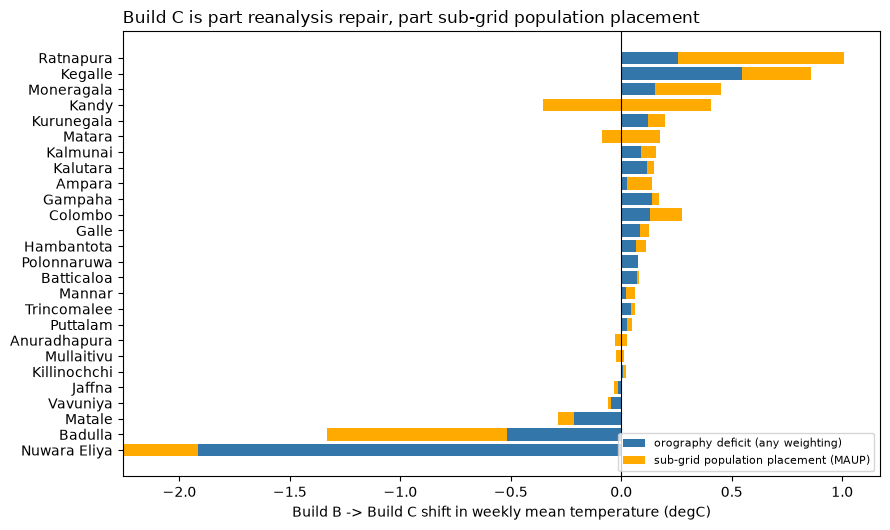

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.barh(dz.rdhs_name, dz.dT_orog, color="#37a", label="orography deficit (any weighting)")
ax.barh(dz.rdhs_name, dz.dT_subgrid, left=dz.dT_orog, color="#fa0",
        label="sub-grid population placement (MAUP)")
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Build B -> Build C shift in weekly mean temperature (degC)")
ax.set_title("Build C is part reanalysis repair, part sub-grid population placement", loc="left")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()

### 6.1 · A check on the coastal cells

ERA5's orography over sea is near zero and slightly negative, so a coastal cell whose land pixels sit
a few tens of metres up receives a small spurious cooling. The correction is right in kind — that land
*is* above the model surface — but it is worth bounding, because `wp5_02` §5 showed some districts draw
~44% of their weight from part-ocean cells.

In [11]:
lowland = dz[dz.dz_pop.abs() < 50]
print(f"districts with |dz_pop| < 50 m: {len(lowland)} of {len(dz)}")
print(f"  their B->C shift: mean |{lowland.dT_c_pop.abs().mean():.3f}| degC, "
      f"max |{lowland.dT_c_pop.abs().max():.3f}| degC")
print(f"\nnegative-orography pairs (cell centre effectively sea): "
      f"{(pair.z_orog < 0).sum()} of {len(pair)}")
print(f"  their share of population weight: "
      f"{100*pair.loc[pair.z_orog < 0, 'pop_sum'].sum()/pair.pop_sum.sum():.2f}%")

districts with |dz_pop| < 50 m: 20 of 26
  their B->C shift: mean |0.099| degC, max |0.212| degC

negative-orography pairs (cell centre effectively sea): 6 of 260
  their share of population weight: 0.94%


## 7 · Rebuild all four arms from the hourly stack

Because RH has to be recomputed per cell per hour under the corrected fields, this section rebuilds
rather than patches. It works on the **260 (district, cell) pair series** instead of the full
18 × 11 grid — every pair needs its own offset anyway, and the pair matrix is smaller than the cube.

Rebuilding also buys the strongest available check on this notebook: setting the offsets to zero must
reproduce `wp5_02`'s frozen Build B table to floating-point precision, through completely different
code. §7.3 asserts exactly that.

In [12]:
def load(var):
    stack, dates = [], []
    for y in range(2018, 2026):
        z = np.load(ERA5 / f"era5_0p25_{var}_{y}.npz")
        stack.append(z["data"]); dates.append(z["dates"])
        assert list(z["window"]) == [I0, I1, J0, J1], f"window differs in {y}"
    A = np.concatenate(stack, axis=0)
    d = pd.to_datetime(np.concatenate(dates))
    assert A.shape[0] == 24 * len(d), "hour count does not match day count"
    return A, d

T2M, days = load("t2m")
D2M, _    = load("d2m")
HOURS = pd.date_range(days[0], periods=T2M.shape[0], freq="h")     # UTC, hourly
print("t2m", T2M.shape, "| d2m", D2M.shape, "|", HOURS[0], "->", HOURS[-1])

# same quantisation handling as wp5_02 section 4: independent int16 scale factors let Td exceed T by
# thousandths at saturation. Bound it, then clip.
excess, frac = (D2M - T2M).max(), float((D2M > T2M).mean())
print(f"d2m > t2m in {100*frac:.4f}% of cell-hours, max excess {excess:.5f} K")
assert excess < 0.01 and frac < 1e-3, "dewpoint exceeds temperature beyond packing resolution"
D2M = np.minimum(D2M, T2M)

# pair series: (hours, 260)
PI, PJ = pair.i.values, pair.j.values
Tp  = (T2M[:, PI, PJ] - 273.15).astype("float32")
Tdp = (D2M[:, PI, PJ] - 273.15).astype("float32")
del T2M, D2M
print("pair series", Tp.shape, "(hours, pairs)")

t2m (70128, 18, 11) | d2m (70128, 18, 11) | 2018-01-01 00:00:00 -> 2025-12-31 23:00:00
d2m > t2m in 0.0184% of cell-hours, max excess 0.00363 K
pair series (70128, 260) (hours, pairs)


### 7.1 · The ISO-week spine — identical to `wp5_02`

In [13]:
dayix = pd.Index(days)
day_of_hour = HOURS.floor("D")

iso = dayix.isocalendar()
spine = pd.DataFrame({"date": dayix, "iso_year": iso.year.values, "iso_week": iso.week.values})
spine = spine[spine.iso_year.between(2018, 2025)]
wk = (spine.groupby(["iso_year", "iso_week"])
      .agg(n_days=("date", "size"), week_start=("date", "min"), week_end=("date", "max"))
      .reset_index().sort_values(["iso_year", "iso_week"]).reset_index(drop=True))
assert (wk.n_days == 7).all() and len(wk) == 417
print("weeks", len(wk), "| all full 7-day spans | boundary weeks:",
      int((wk.week_start.dt.year != wk.week_end.dt.year).sum()))

pos = {d: i for i, d in enumerate(dayix)}
WEEK_IX = [[pos[d] for d in pd.date_range(r.week_start, r.week_end)] for _, r in wk.iterrows()]

weeks 417 | all full 7-day spans | boundary weeks: 6


### 7.2 · One function, four arms

`build(dz_t, dz_td)` applies a per-pair offset, recomputes RH per pair per hour, then walks
hourly → daily → weekly exactly as `wp5_02` §7 does. Passing zeros gives the uncorrected arms.

In [14]:
A_MAG, B_MAG = 17.625, 243.04          # Alduchov-Eskridge Magnus, as wp5_02 section 6

def build(dz_t, dz_td):
    # dz_t, dz_td: per-pair elevation gap (m); returns dict of weekly (417, npairs) arrays.
    # Hourly -> daily -> weekly, the same two-stage reduction wp5_02 section 7 uses: the weekly min
    # is the min of the DAILY minima, not of the hourly values, so it matches the frozen twin.
    t  = Tp  - (LAPSE_T  * dz_t).astype("float32")
    td = np.minimum(Tdp - (LAPSE_TD * dz_td).astype("float32"), t)
    rh = np.clip(100.0 * np.exp(A_MAG * td / (B_MAG + td)) / np.exp(A_MAG * t / (B_MAG + t)), 0, 100)

    out = {}
    for name, A, how in [("t2m_mean_c", t, "mean"), ("t2m_min_c", t, "min"),
                         ("t2m_max_c", t, "max"), ("d2m_mean_c", td, "mean"),
                         ("rh_mean_percent", rh, "mean")]:
        d_ = getattr(pd.DataFrame(A).groupby(day_of_hour), how)().values      # (days, pairs)
        agg = {"min": np.min, "max": np.max, "mean": np.mean}[how]
        out[name] = np.stack([agg(d_[ix], axis=0) for ix in WEEK_IX]).astype("float32")
    return out

In [15]:
zero = np.zeros(len(pair))
gap_pop  = (pair.z_pop  - pair.z_orog).values
gap_area = (pair.z_area - pair.z_orog).values

UNCORR = build(zero, zero)
CORR   = build(gap_pop, gap_pop)       # Build C: pop-weighted cells get their population's elevation
CORR_A = build(gap_area, gap_area)     # area-weighted counterpart, for the decomposition
print("weekly pair arrays:", {k: v.shape for k, v in UNCORR.items()})

weekly pair arrays: {'t2m_mean_c': (417, 260), 't2m_min_c': (417, 260), 't2m_max_c': (417, 260), 'd2m_mean_c': (417, 260), 'rh_mean_percent': (417, 260)}


### 7.3 · The check: zero offsets must reproduce the frozen Build B table

In [16]:
VARS = ["t2m_mean_c", "t2m_min_c", "t2m_max_c", "d2m_mean_c", "rh_mean_percent"]

def to_district(weightcol, source):
    # weekly (417, npairs) arrays -> tidy district-week frame, using `weightcol` from `pair`
    rows = []
    for gid, g in pair.groupby("geometry_id"):
        ix, wts = g.index.values, g[weightcol].values
        d = {"geometry_id": gid, "rdhs_name": g.rdhs_name.iloc[0],
             "iso_year": wk.iso_year.values, "iso_week": wk.iso_week.values}
        for v in VARS:
            d[v] = source[v][:, ix] @ wts
        rows.append(pd.DataFrame(d))
    return pd.concat(rows, ignore_index=True).sort_values(
        ["iso_year", "iso_week", "geometry_id"]).reset_index(drop=True)

b_here = to_district("w_pop", UNCORR)
froz = pd.read_csv(QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv")
m = froz.merge(b_here, on=["geometry_id", "iso_year", "iso_week"], suffixes=("_f", "_h"))
assert len(m) == 10842, f"join lost rows: {len(m)}"
worst = {v: float(np.abs(m[f"{v}_b_pop"] - m[v]).max()) for v in VARS}
for v, e in worst.items():
    print(f"{v:<18} max |frozen - rebuilt| = {e:.3e}")
assert max(worst.values()) < 5e-4, "rebuilt Build B does not match the frozen twin"
print("\nBuild B reproduced through an independent code path — the pipeline is sound")

t2m_mean_c         max |frozen - rebuilt| = 3.553e-15
t2m_min_c          max |frozen - rebuilt| = 3.553e-15
t2m_max_c          max |frozen - rebuilt| = 7.105e-15
d2m_mean_c         max |frozen - rebuilt| = 3.553e-15
rh_mean_percent    max |frozen - rebuilt| = 1.651e-05

Build B reproduced through an independent code path — the pipeline is sound


## 8 · Assemble the Build C table

Four arms, row-aligned to the 10,842 keys of Builds A′/B, plus the B→C differences.

In [17]:
arms = {"a_frac": ("w_area", UNCORR), "b_pop": ("w_pop", UNCORR),
        "c_frac": ("w_area", CORR_A), "c_pop": ("w_pop", CORR)}

exp = None
for arm, (wcol, src) in arms.items():
    t = to_district(wcol, src).rename(columns={v: f"{v}_{arm}" for v in VARS})
    exp = t if exp is None else exp.merge(t, on=["geometry_id", "rdhs_name", "iso_year", "iso_week"])

exp = exp.merge(wk[["iso_year", "iso_week", "week_start", "week_end"]], on=["iso_year", "iso_week"])
exp["n_era5_hours"] = 168
for v in VARS:
    exp[f"d_lapse_{v}"] = exp[f"{v}_c_pop"] - exp[f"{v}_b_pop"]      # B -> C
    exp[f"d_total_{v}"] = exp[f"{v}_c_pop"] - exp[f"{v}_a_frac"]     # A' -> C, the full ladder
exp = exp.sort_values(["iso_year", "iso_week", "geometry_id"]).reset_index(drop=True)
print("exposure table", exp.shape, "| rows expected", 417 * 26, "->", len(exp) == 417 * 26)
exp[["rdhs_name", "iso_year", "iso_week", "t2m_mean_c_b_pop", "t2m_mean_c_c_pop",
     "rh_mean_percent_b_pop", "rh_mean_percent_c_pop"]].head()

exposure table (10842, 37) | rows expected 10842 -> True


,rdhs_name,iso_year,iso_week,t2m_mean_c_b_pop,t2m_mean_c_c_pop,rh_mean_percent_b_pop,rh_mean_percent_c_pop
0,Colombo,2018,1,26.631902,26.761976,65.182765,64.791957
1,Gampaha,2018,1,26.419707,26.557973,65.747647,65.332732
2,Kalutara,2018,1,25.880521,26.030625,72.160602,71.655510
3,Kandy,2018,1,21.192611,21.600587,79.561477,77.954494
4,Matale,2018,1,22.878156,22.665758,79.459222,80.199371


### 8.1 · The dewpoint lapse rate is a choice — bracket it

In [18]:
# Td falls with height much more slowly than T. The two bounds are physically named:
#   0.0 degC/km  -> vapour pressure conserved; RH rises as the air cools
#   6.5 degC/km  -> RH conserved by construction, so RH carries no Build C signal at all
bracket = {}
for name, g_td in [("Td 0.0 (vapour pressure conserved)", 0.0),
                   ("Td 1.5 (used here)", 1.5 / 1000),
                   ("Td 6.5 (RH conserved)", 6.5 / 1000)]:
    t  = Tp - (LAPSE_T * gap_pop).astype("float32")
    td = np.minimum(Tdp - (g_td * gap_pop).astype("float32"), t)
    rh = np.clip(100.0 * np.exp(A_MAG*td/(B_MAG+td)) / np.exp(A_MAG*t/(B_MAG+t)), 0, 100)
    d_ = pd.DataFrame(rh).groupby(day_of_hour).mean().values
    wkly = np.stack([d_[ix].mean(axis=0) for ix in WEEK_IX])
    per_d = {g.rdhs_name.iloc[0]: float((wkly[:, g.index.values] @ g.w_pop.values).mean())
             for _, g in pair.groupby("geometry_id")}
    base = exp.groupby("rdhs_name").rh_mean_percent_b_pop.mean()
    shift = pd.Series(per_d) - base
    bracket[name] = shift
    print(f"{name:<38} RH shift: mean {shift.mean():+.2f} pp | "
          f"range {shift.min():+.2f} .. {shift.max():+.2f} pp")

print("\nThe RH result is bounded by the dewpoint rate, not measured independently of it.")
print("Report it as a bracket; do not quote the middle number alone.")

Td 0.0 (vapour pressure conserved)     RH shift: mean -0.34 pp | range -5.02 .. +6.34 pp


Td 1.5 (used here)                     RH shift: mean -0.23 pp | range -3.88 .. +5.37 pp


Td 6.5 (RH conserved)                  RH shift: mean +0.00 pp | range -0.17 .. +0.09 pp

The RH result is bounded by the dewpoint rate, not measured independently of it.
Report it as a bracket; do not quote the middle number alone.


## 9 · The finding that decides whether Build C can move a decision

§5 predicted it and §8 can now confirm it: for `t2m`, Build C is Build B plus a **constant
per-district offset**.

> **Amended 2026-08-13 (markdown only; no output re-run).** This section originally read "for `t2m`
> *and* `d2m`". The cell below tests `t2m` and asserts it; `d2m` was asserted without being tested,
> and it is **not** a constant offset. `wp5_03` §8.1 measures it against the exact −Γ·Δz prediction:
> `t2m` matches to 6×10⁻⁷ °C, `d2m` departs by up to **0.46 °C** (Nuwara Eliya) because the
> saturation guard `td = min(td − Γ_td·Δz, t − Γ_t·Δz)` in §7.2 binds in some hours and not others,
> in three highland districts. The consequence below therefore applies to *temperature*; a model
> carrying dewpoint or humidity sees a residual no district effect can absorb. Nothing about the *shape* of a district's time series changes — no week moves
relative to another week in the same district.

This is not a technicality. It determines, structurally and before any model is fitted, what Build C
can and cannot do to an alert decision:

- a model using **district-relative** temperature (anomalies, district fixed effects, per-district
  standardisation) absorbs the offset entirely → Build C **cannot** change a single decision;
- a model using **absolute** temperature, or any **fixed thermal threshold**, sees the full ~2 °C in
  the highlands → Build C can change many.

So "does exposure construction move decisions?" has a *different* answer for the A→B rung than for
the B→C rung, and the difference is a property of the downstream model, not of the exposure table.
That is stated here so it cannot be discovered later and mistaken for a null result.

**Three quantities survive district-relative modelling**: RH (nonlinear, §8.1), **dewpoint** (clipped
at saturation, see the amendment above) and any threshold-crossing count. DTR does not — `t2m_max − t2m_min` is offset-invariant.

In [19]:
sd = exp.groupby("rdhs_name")["d_lapse_t2m_mean_c"].agg(["mean", "std", "min", "max"])
print("per-district B->C shift in weekly mean t2m (degC):\n")
print(sd.round(6).to_string())
print(f"\nlargest within-district standard deviation across 417 weeks: {sd['std'].max():.2e} degC")
assert sd["std"].max() < 1e-5, "the t2m correction is not time-invariant — check the build"
print("time-invariant to floating-point precision, as section 5 derived")

dtr_b = exp.t2m_max_c_b_pop - exp.t2m_min_c_b_pop
dtr_c = exp.t2m_max_c_c_pop - exp.t2m_min_c_c_pop
print(f"\nDTR: max |Build C - Build B| = {float((dtr_c - dtr_b).abs().max()):.2e} degC (offset-invariant)")

rh_sd = exp.groupby("rdhs_name")["d_lapse_rh_mean_percent"].std()
print(f"RH : within-district sd of the shift, max {rh_sd.max():.3f} pp — RH DOES vary week to week")

per-district B->C shift in weekly mean t2m (degC):

                  mean       std       min       max
rdhs_name                                           
Ampara        0.139305  0.000001  0.139303  0.139307
Anuradhapura  0.024923  0.000001  0.024921  0.024925
Badulla      -1.333308  0.000001 -1.333311 -1.333305
Batticaloa    0.069535  0.000001  0.069532  0.069538
Colombo       0.130073  0.000001  0.130070  0.130077
Galle         0.126598  0.000001  0.126595  0.126600
Gampaha       0.138264  0.000001  0.138261  0.138267
Hambantota    0.114216  0.000001  0.114214  0.114218
Jaffna       -0.033571  0.000002 -0.033576 -0.033567
Kalmunai      0.159324  0.000001  0.159322  0.159328
Kalutara      0.150104  0.000001  0.150101  0.150107
Kandy         0.407976  0.000001  0.407972  0.407980
Kegalle       0.860671  0.000001  0.860669  0.860673
Killinochchi  0.007753  0.000001  0.007750  0.007755
Kurunegala    0.196994  0.000001  0.196992  0.196995
Mannar        0.062051  0.000001  0.062049  0.0

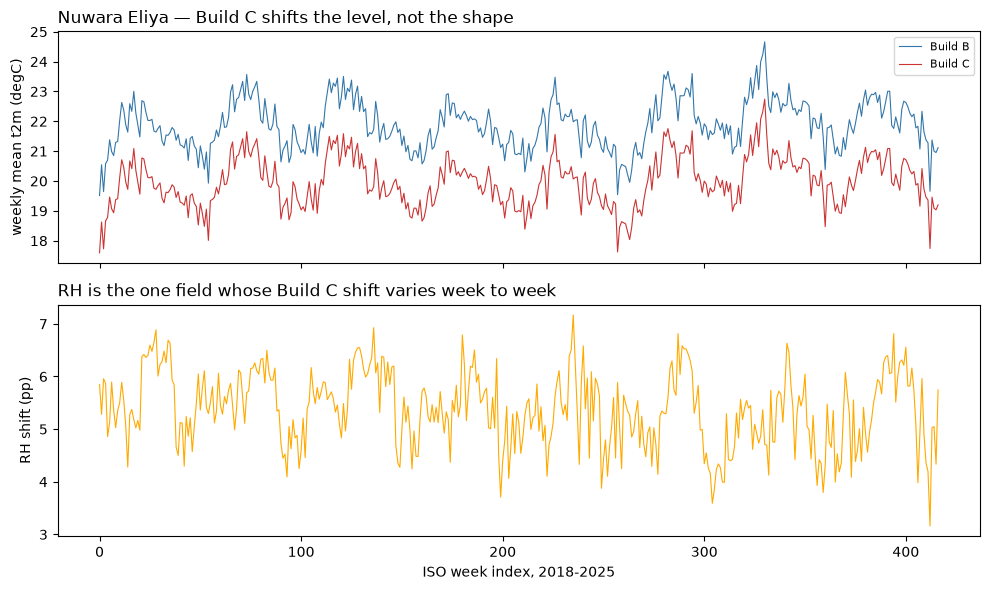

In [20]:
d = exp[exp.rdhs_name == "Nuwara Eliya"].sort_values(["iso_year", "iso_week"])
x = np.arange(len(d))
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(x, d.t2m_mean_c_b_pop, lw=.8, color="#37a", label="Build B")
ax[0].plot(x, d.t2m_mean_c_c_pop, lw=.8, color="#c33", label="Build C")
ax[0].set_ylabel("weekly mean t2m (degC)"); ax[0].legend(fontsize=8)
ax[0].set_title("Nuwara Eliya — Build C shifts the level, not the shape", loc="left")
ax[1].plot(x, d.d_lapse_rh_mean_percent, lw=.8, color="#fa0")
ax[1].set_ylabel("RH shift (pp)"); ax[1].set_xlabel("ISO week index, 2018-2025")
ax[1].set_title("RH is the one field whose Build C shift varies week to week", loc="left")
plt.tight_layout()

## 10 · Is 6.5 °C/km the right rate here? Three independent estimates

The Build C magnitudes are proportional to an assumed rate, so the rate has to be argued rather than
declared. Three estimates are available, and they are **not** of equal quality — that ordering matters
more than the numbers, because the weakest of the three is the easiest to compute and was very nearly
allowed to carry the conclusion on its own.

### 10.1 · MODIS-anchored bracket — the weakest of the three

Plan §3.1b asks for a sensitivity on the rate, "locally-fit or MODIS-LST-anchored". The M6 build
already staged MODIS Terra LST as 8-day district composites, so the local rate can be estimated by
regressing district LST on district mean elevation, one composite at a time.

**This is a bracket, not a measurement, and three caveats bound it.** LST is a *surface* temperature,
not 2 m air temperature; the regression is *between* districts, so land cover and latitude are
confounded with elevation; and daytime LST exaggerates lapse because high ground heats differently.
Night LST is the closer analogue of the air-temperature lapse rate, so it is the one to read.

In [21]:
lst = pd.read_csv(M6 / "m6_lst_terra_8day_srilanka.csv")
terr = pd.read_csv(M6 / "m6_batchA_terrain_srilanka.csv")[["rdhs_name", "elev_mean"]]
L = lst.merge(terr, on="rdhs_name").dropna(subset=["elev_mean"])

def rate(col):
    g = L.dropna(subset=[col]).groupby("composite_start")
    s = g.apply(lambda d: np.polyfit(d.elev_mean, d[col], 1)[0] * -1000
                if len(d) >= 15 else np.nan, include_groups=False).dropna()
    return s

for col, lab in [("lst_night_mean", "night LST (closest analogue)"),
                 ("lst_day_mean", "day LST (upper bound)")]:
    s = rate(col)
    print(f"{lab:<32} n={len(s):>4} composites | median {s.median():.2f} "
          f"[{s.quantile(.1):.2f}, {s.quantile(.9):.2f}] degC/km")

s = rate("lst_night_mean")
MODIS_RATE = float(s.median())
print(f"\nstandard environmental rate used here: {1000*LAPSE_T:.1f} degC/km")
print(f"night-LST median {MODIS_RATE:.2f} sits {'below' if MODIS_RATE < 1000*LAPSE_T else 'above'} it.")
print("Do NOT draw the conclusion here: sections 10.2 and 10.3 estimate the same quantity from air")
print("temperature rather than surface temperature, and they disagree with this one.")

night LST (closest analogue)     n= 302 composites | median 5.84 [5.03, 7.70] degC/km
day LST (upper bound)            n= 349 composites | median 4.56 [2.76, 6.78] degC/km

standard environmental rate used here: 6.5 degC/km
night-LST median 5.84 sits below it.
Do NOT draw the conclusion here: sections 10.2 and 10.3 estimate the same quantity from air
temperature rather than surface temperature, and they disagree with this one.


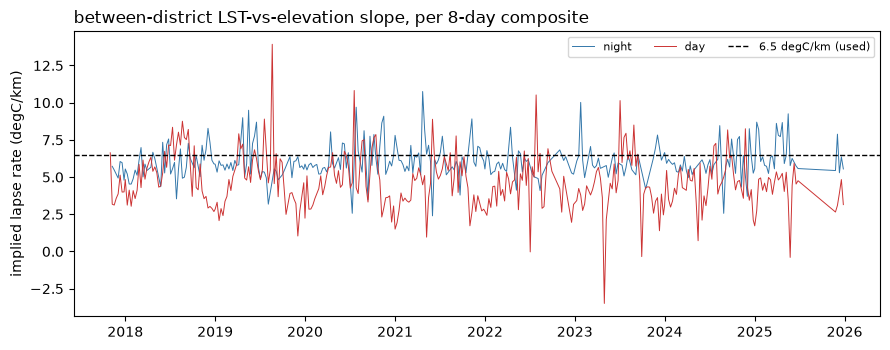

In [22]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for col, c, lab in [("lst_night_mean", "#37a", "night"), ("lst_day_mean", "#c33", "day")]:
    s = rate(col)
    ax.plot(pd.to_datetime(s.index), s.values, lw=.7, color=c, label=lab)
ax.axhline(1000 * LAPSE_T, color="k", ls="--", lw=1, label="6.5 degC/km (used)")
ax.set_ylabel("implied lapse rate (degC/km)"); ax.legend(fontsize=8, ncol=3)
ax.set_title("between-district LST-vs-elevation slope, per 8-day composite", loc="left")
plt.tight_layout()

### 10.2 · ERA5's own between-cell lapse rate

A second estimate needs no external data at all. ERA5 assigns each cell both a temperature and an
orography, so regressing one on the other across the window's land cells recovers the lapse rate the
reanalysis itself behaves with. That is the most directly relevant quantity of all: Build C extends
ERA5's own field below its own grid, so the right rate to extend with is the one ERA5 is already using.

Sea-blended cells are excluded — over water the orography is ~0 and the temperature is an SST, which
would flatten the slope toward zero and understate the rate.

In [23]:
Tsum, n = np.zeros(OROG.shape), 0
for y in range(2018, 2026):
    zz = np.load(ERA5 / f"era5_0p25_t2m_{y}.npz")["data"]
    Tsum += zz.sum(axis=0); n += zz.shape[0]
Tmean = Tsum / n - 273.15

land_cell = OROG > 30                       # clearly land; drops the sea-blended cells
ERA5_RATE = -1000 * np.polyfit(OROG[land_cell], Tmean[land_cell], 1)[0]
print(f"ERA5's own between-cell lapse rate over {land_cell.sum()} land cells: "
      f"{ERA5_RATE:.2f} degC/km")
print(f"the rate used here: {1000*LAPSE_T:.1f} degC/km -> agreement to "
      f"{100*abs(ERA5_RATE-1000*LAPSE_T)/(1000*LAPSE_T):.0f}%")
print("\nno station, no MODIS, no DEM — this is internal to the reanalysis being corrected")

ERA5's own between-cell lapse rate over 71 land cells: 6.36 degC/km
the rate used here: 6.5 degC/km -> agreement to 2%

no station, no MODIS, no DEM — this is internal to the reanalysis being corrected


### 10.3 · Station air temperature — the estimate that should carry the most weight

The other two are proxies: MODIS measures a *surface*, and §10.2 measures how ERA5 behaves rather than
how the atmosphere does. The quantity Build C actually corrects is **2 m air temperature**, and that is
observed directly.

GHCN-Daily carries six Sri Lankan stations reporting TMAX/TMIN into 2025 — free, anonymous, no account,
consistent with every other source in this build. Critically, one of them is **Nuwara Eliya at 1,880 m**
(`CE000434730`, a GSN station with a record from 1869); the other five sit between 1.8 and 116 m. That
single high station is what makes a lapse estimate possible at all, and also the main limitation of it.

In [24]:
import urllib.request

GHCN = QUAR / "ghcn"
GHCN.mkdir(exist_ok=True)
STN = {  # id: (name, lat, lon, elevation_m) — from ghcnd-stations.txt
    "CE000434730": ("Nuwara Eliya", 6.967, 80.767, 1880.0),
    "CEM00043441": ("Kurunegala",   7.467, 80.367,  116.0),
    "CE000043497": ("Hambantota",   6.117, 81.133,   20.0),
    "CEM00043466": ("Colombo",      6.900, 79.867,    7.0),
    "CEM00043424": ("Puttalam",     8.033, 79.833,    2.0),
    "CEM00043418": ("China Bay",    8.539, 81.182,    1.8),
}
for sid in STN:
    f = GHCN / f"{sid}.dly"
    if not f.exists():
        urllib.request.urlretrieve(
            f"https://www.ncei.noaa.gov/pub/data/ghcn/daily/all/{sid}.dly", f)
print("station files cached:", len(list(GHCN.glob("*.dly"))))

# GHCN .dly is fixed-width: id(11) year(4) month(2) element(4) then 31 x [value(5) m(1) q(1) s(1)].
# Values are tenths of degC; -9999 is missing; a non-blank QFLAG means the value failed QC -> drop it.
def read_dly(path):
    rec = []
    for ln in open(path):
        el = ln[17:21]
        if el not in ("TMAX", "TMIN"):
            continue
        y, mo = int(ln[11:15]), int(ln[15:17])
        if not (2018 <= y <= 2025):
            continue
        for d in range(31):
            o = 21 + d * 8
            v, q = int(ln[o:o + 5]), ln[o + 6]
            if v == -9999 or q.strip():
                continue
            rec.append((pd.Timestamp(y, mo, d + 1), el, v / 10.0))
    t = pd.DataFrame(rec, columns=["date", "el", "v"]).pivot_table(
        index="date", columns="el", values="v").dropna(subset=["TMAX", "TMIN"])
    t["tmean_stn"] = (t.TMAX + t.TMIN) / 2
    return t

obs = {sid: read_dly(GHCN / f"{sid}.dly") for sid in STN}
for sid, (nm, *_) in STN.items():
    print(f"{nm:<13} {len(obs[sid]):>5} days with both TMAX and TMIN")

station files cached: 6
Nuwara Eliya   1938 days with both TMAX and TMIN
Kurunegala     1907 days with both TMAX and TMIN
Hambantota      121 days with both TMAX and TMIN
Colombo        1972 days with both TMAX and TMIN
Puttalam       1842 days with both TMAX and TMIN
China Bay      1572 days with both TMAX and TMIN


#### Comparing like with like

Two mismatches would each manufacture a spurious bias of about the size being measured, so both are
handled rather than noted:

- **A station's daily mean is `(TMAX+TMIN)/2`, not a true mean.** ERA5's daily max and min are taken
  and averaged the same way. (§11 measures what that convention is worth: +0.55 °C at this cell.)
- **ERA5 hours are UTC; Sri Lanka is UTC+5:30.** Daily extremes are formed on **local** days. Grouping
  on UTC days splits each local night across two records and damps the minimum.

In [25]:
T2M_g, _ = load("t2m")                       # reload: section 7 kept only the pair series
T2M_g = T2M_g - 273.15
LOCAL_DAY = (HOURS + pd.Timedelta(hours=5, minutes=30)).floor("D")

rows = []
for sid, (nm, lat, lon, z_stn) in STN.items():
    i = int(round((90 - lat) / 0.25)) - I0
    j = int(round(lon / 0.25)) - J0
    d = pd.DataFrame({"d": LOCAL_DAY, "t": T2M_g[:, i, j]}).groupby("d").t.agg(["max", "min"])
    m = obs[sid].join(((d["max"] + d["min"]) / 2).rename("tmean_era5"), how="inner").dropna(
        subset=["tmean_stn", "tmean_era5"])
    rows.append(dict(station=nm, n_days=len(m), z_stn=z_stn, z_orog=float(OROG[i, j]),
                     gap_m=z_stn - float(OROG[i, j]),
                     stn_C=float(m.tmean_stn.mean()), era5_C=float(m.tmean_era5.mean()),
                     bias_C=float((m.tmean_era5 - m.tmean_stn).mean())))
del T2M_g

st = pd.DataFrame(rows).sort_values("z_stn", ascending=False)
st["bias_pred_C"] = st.gap_m * LAPSE_T
print(st.round(2).to_string(index=False))

low = st[st.z_stn < 200]
print(f"\nlowland stations (n={len(low)}): ERA5 bias {low.bias_C.mean():+.2f} degC "
      f"(sd {low.bias_C.std():.2f})")
print(f"Nuwara Eliya (1,880 m)      : ERA5 bias {st.iloc[0].bias_C:+.2f} degC "
      f"at a {st.iloc[0].gap_m:.0f} m gap")
print("\nERA5 is accurate at sea level and several degrees too warm in the highlands.")
print("That is an ELEVATION-DEPENDENT error — what Build C models — not a global offset.")

     station  n_days  z_stn  z_orog  gap_m  stn_C  era5_C  bias_C  bias_pred_C
Nuwara Eliya    1938 1880.0 1219.26 660.74  16.40   21.17    4.77         4.29
  Kurunegala    1907  116.0  120.49  -4.49  27.93   27.51   -0.42        -0.03
  Hambantota     121   20.0   11.35   8.65  28.37   27.00   -1.37         0.06
     Colombo    1972    7.0    6.22   0.78  28.13   27.77   -0.36         0.01
    Puttalam    1842    2.0   14.18 -12.18  28.27   27.87   -0.41        -0.08
   China Bay    1572    1.8   11.71  -9.91  28.66   28.29   -0.37        -0.06

lowland stations (n=5): ERA5 bias -0.59 degC (sd 0.44)
Nuwara Eliya (1,880 m)      : ERA5 bias +4.77 degC at a 661 m gap

ERA5 is accurate at sea level and several degrees too warm in the highlands.
That is an ELEVATION-DEPENDENT error — what Build C models — not a global offset.


In [26]:
# the rate itself: observed temperature against station elevation, well-sampled stations only
good = st[st.n_days > 1000]
slope, icept = np.polyfit(good.z_stn, good.stn_C, 1)
STN_RATE = -1000 * slope
print(f"station regression over {len(good)} stations with >1000 days:")
print(f"  T = {icept:.2f} - {STN_RATE:.2f} degC/km * z      <- observed AIR temperature")

print(f"\n{'estimate':<44}{'rate':>10}   quality")
print(f"{'-'*70}")
print(f"{'station air temperature (10.3)':<44}{STN_RATE:>7.2f} C/km   best: the quantity being corrected")
print(f"{'ERA5 internal, between-cell (10.2)':<44}{ERA5_RATE:>7.2f} C/km   good: what the field already does")
print(f"{'MODIS night LST, between-district (10.1)':<44}{MODIS_RATE:>7.2f} C/km   weakest: surface, confounded")
print(f"{'USED IN THIS NOTEBOOK':<44}{1000*LAPSE_T:>7.2f} C/km")
print(f"\nThe two air-temperature estimates bracket the rate used to within "
      f"{max(abs(STN_RATE-1000*LAPSE_T), abs(ERA5_RATE-1000*LAPSE_T))/(1000*LAPSE_T)*100:.0f}%.")
print("Had 10.1 been read alone it would have argued for scaling Build C down by ~10%; on the better")
print("evidence no rescaling is warranted. This is why the ordering of the three matters.")

station regression over 5 stations with >1000 days:
  T = 28.45 - 6.40 degC/km * z      <- observed AIR temperature

estimate                                          rate   quality
----------------------------------------------------------------------
station air temperature (10.3)                 6.40 C/km   best: the quantity being corrected
ERA5 internal, between-cell (10.2)             6.36 C/km   good: what the field already does
MODIS night LST, between-district (10.1)       5.84 C/km   weakest: surface, confounded
USED IN THIS NOTEBOOK                          6.50 C/km

The two air-temperature estimates bracket the rate used to within 2%.
Had 10.1 been read alone it would have argued for scaling Build C down by ~10%; on the better
evidence no rescaling is warranted. This is why the ordering of the three matters.


## 11 · Does Build C actually land closer to the ground truth?

§10 validates the *rate*. This validates the *output*, which is the sharper question, and it is asked
where the correction is largest and therefore most exposed: **Nuwara Eliya**.

The station cannot be used directly — it sits at 1,880 m while the district's population lives at
1,260 m, and Build C's number is for the population. So the station **regression** is interpolated to
1,260 m, which sits between Kurunegala (116 m) and Nuwara Eliya (1,880 m): interpolation, not
extrapolation. The `(TMAX+TMIN)/2` convention is then removed, measured from ERA5 at this cell rather
than assumed.

If Build C is right, it should land near that target and Build B should not.

In [27]:
NE = "Nuwara Eliya"
ne = exp[exp.rdhs_name == NE]
b_val, c_val = float(ne.t2m_mean_c_b_pop.mean()), float(ne.t2m_mean_c_c_pop.mean())

z_pop_ne = float(dz.loc[dz.rdhs_name == NE, "dz_pop"].iloc[0]
                 + pair.loc[pair.rdhs_name == NE].pipe(
                     lambda d: np.average(d.z_orog, weights=d.w_pop)))
target_mm = icept + slope * z_pop_ne                      # (TMAX+TMIN)/2 at that elevation

i = int(round((90 - STN["CE000434730"][1]) / 0.25)) - I0
j = int(round(STN["CE000434730"][2] / 0.25)) - J0
zz = np.concatenate([np.load(ERA5 / f"era5_0p25_t2m_{y}.npz")["data"][:, i, j]
                     for y in range(2018, 2026)]) - 273.15
dd = pd.DataFrame({"d": LOCAL_DAY, "t": zz}).groupby("d").t.agg(["max", "min", "mean"])
conv = float(((dd["max"] + dd["min"]) / 2 - dd["mean"]).mean())
target = target_mm - conv

print(f"{NE} district, population-weighted elevation {z_pop_ne:.0f} m\n")
print(f"  station regression at {z_pop_ne:.0f} m, (TMAX+TMIN)/2 : {target_mm:.2f} degC")
print(f"  minus the (max+min)/2 convention (measured)      : {conv:+.2f} degC")
print(f"  -> station-implied TRUE mean                     : {target:.2f} degC\n")
print(f"  Build B (uncorrected)  {b_val:.2f} degC   error {b_val-target:+.2f} degC")
print(f"  Build C (lapse corr.)  {c_val:.2f} degC   error {c_val-target:+.2f} degC")
print(f"\nBuild C removes {100*(1-abs(c_val-target)/abs(b_val-target)):.0f}% of Build B's error, "
      f"at the district where the correction is largest.")

Nuwara Eliya district, population-weighted elevation 1260 m

  station regression at 1260 m, (TMAX+TMIN)/2 : 20.38 degC
  minus the (max+min)/2 convention (measured)      : +0.55 degC
  -> station-implied TRUE mean                     : 19.82 degC

  Build B (uncorrected)  21.89 degC   error +2.07 degC
  Build C (lapse corr.)  19.98 degC   error +0.15 degC

Build C removes 93% of Build B's error, at the district where the correction is largest.


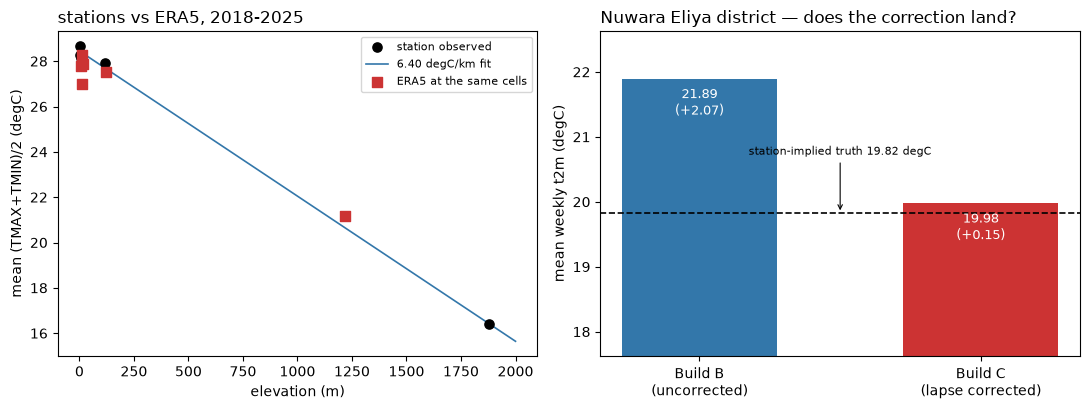

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].scatter(good.z_stn, good.stn_C, s=44, color="k", zorder=3, label="station observed")
zz_ = np.linspace(0, 2000, 50)
ax[0].plot(zz_, icept + slope * zz_, color="#37a", lw=1.2,
           label=f"{STN_RATE:.2f} degC/km fit")
ax[0].scatter(st.z_orog, st.era5_C, s=44, marker="s", color="#c33", zorder=3,
              label="ERA5 at the same cells")
ax[0].set_xlabel("elevation (m)"); ax[0].set_ylabel("mean (TMAX+TMIN)/2 (degC)")
ax[0].set_title("stations vs ERA5, 2018-2025", loc="left"); ax[0].legend(fontsize=8)

lbl = ["Build B\n(uncorrected)", "Build C\n(lapse corrected)"]
ax[1].bar(lbl, [b_val, c_val], color=["#37a", "#c33"], width=.55)
ax[1].axhline(target, color="k", ls="--", lw=1.2)
ax[1].annotate(f"station-implied truth {target:.2f} degC", (0.5, target), xytext=(0.5, target + 0.9),
               ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", lw=.8))
for k, v in enumerate([b_val, c_val]):
    ax[1].text(k, v - 0.55, f"{v:.2f}\n({v-target:+.2f})", ha="center", color="w", fontsize=9)
ax[1].set_ylim(target - 2.2, target + 2.8); ax[1].set_ylabel("mean weekly t2m (degC)")
ax[1].set_title(f"{NE} district — does the correction land?", loc="left")
plt.tight_layout()

### 11.1 · What the station check does not license

Three limits, all visible in the numbers above and none of them removable with the data available:

- **The high end rests on one station.** Four of the five well-sampled stations sit below 120 m, so the
  regression's slope is effectively a two-point estimate with Nuwara Eliya as the sole anchor. A second
  highland station would change the confidence in this far more than more years of the same six.
- **The station's own minimum is not the district's.** The bias is larger in TMIN than in TMAX — the
  signature of **nocturnal cold-air pooling** in a highland basin, which a 0.25° cell cannot resolve.
  That is a local siting effect. It should not be extrapolated to the district's whole population, and
  it is the likely reason the raw station-minus-ERA5 gap implies a steeper rate (~7.8 °C/km) than the
  clean regression's ~6.4.
- **Agreement at one district is not agreement everywhere.** Nuwara Eliya is the largest correction and
  therefore the most informative single test, but it is one test. The lowland stations confirm the
  *absence* of a spurious correction where none is due, which is the other half of the check and the
  half most easily forgotten.

In [29]:
print("TMAX vs TMIN, Nuwara Eliya — the cold-air-pooling signature, stated as a number:")
mm = obs["CE000434730"].join(dd[["max", "min"]], how="inner").dropna()
print(f"  daily MAX: ERA5 - station {(mm['max']-mm.TMAX).mean():+.2f} degC")
print(f"  daily MIN: ERA5 - station {(mm['min']-mm.TMIN).mean():+.2f} degC")
print(f"  diurnal range: station {(mm.TMAX-mm.TMIN).mean():.2f} degC vs "
      f"ERA5 {(mm['max']-mm['min']).mean():.2f} degC")

mm["yr"] = mm.index.year
byyr = mm.groupby("yr").apply(
    lambda g: pd.Series({"n": len(g),
                         "bias_C": ((g["max"] + g["min"]) / 2 - g.tmean_stn).mean()}),
    include_groups=False)
print(f"\nby year (the bias is not an artifact of one season or one year):")
print(byyr.round(2).to_string())
assert byyr.bias_C.min() > 3.5, "highland warm bias not stable across years"

TMAX vs TMIN, Nuwara Eliya — the cold-air-pooling signature, stated as a number:
  daily MAX: ERA5 - station +4.27 degC
  daily MIN: ERA5 - station +5.27 degC
  diurnal range: station 7.58 degC vs ERA5 6.57 degC

by year (the bias is not an artifact of one season or one year):
          n  bias_C
yr                 
2018  218.0    4.69
2019  225.0    4.88
2020  276.0    4.96
2021  289.0    4.74
2022  198.0    4.66
2023  255.0    4.61
2024  132.0    4.34
2025  345.0    4.99


## 12 · QC

In [30]:
checks = {
    "rows = 417 x 26":            len(exp) == 10842,
    "26 districts":               exp.geometry_id.nunique() == 26,
    "417 ISO weeks":              exp.groupby(["iso_year", "iso_week"]).ngroups == 417,
    "no duplicate keys":          not exp.duplicated(["iso_year", "iso_week", "geometry_id"]).any(),
    "no nulls":                   not exp.isna().any().any(),
    "row-aligned to Build B":     len(froz.merge(exp, on=["geometry_id", "iso_year", "iso_week"])) == 10842,
    "n_era5_hours = 168":         (exp.n_era5_hours == 168).all(),
    "t2m_c_pop in 10..35 degC":   exp.t2m_mean_c_c_pop.between(10, 35).all(),
    "RH within 0..100":           exp.rh_mean_percent_c_pop.between(0, 100).all(),
    "dewpoint <= temperature":    (exp.d2m_mean_c_c_pop <= exp.t2m_mean_c_c_pop).all(),
    "min <= mean <= max":         bool((exp.t2m_min_c_c_pop <= exp.t2m_mean_c_c_pop).all()
                                       and (exp.t2m_mean_c_c_pop <= exp.t2m_max_c_c_pop).all()),
    "C cooler where land is high": bool(exp.loc[exp.rdhs_name == "Nuwara Eliya",
                                                "d_lapse_t2m_mean_c"].mean() < -1.0),
    "t2m correction time-invariant": sd["std"].max() < 1e-5,
    "Build C closer to stations":  abs(c_val - target) < abs(b_val - target),
    "Build C within 0.5 C of truth": abs(c_val - target) < 0.5,
    "air-temp rates bracket 6.5":  bool(abs(STN_RATE - 1000*LAPSE_T) / (1000*LAPSE_T) < 0.10
                                        and abs(ERA5_RATE - 1000*LAPSE_T) / (1000*LAPSE_T) < 0.10),
    "ERA5 unbiased in the lowlands": bool(st[st.z_stn < 200].bias_C.abs().mean() < 1.0),
}
for k, v in checks.items():
    print(f"{k:<32} {'PASS' if v else 'FAIL'}")
assert all(checks.values()), "QC failed"

rows = 417 x 26                  PASS
26 districts                     PASS
417 ISO weeks                    PASS
no duplicate keys                PASS
no nulls                         PASS
row-aligned to Build B           PASS
n_era5_hours = 168               PASS
t2m_c_pop in 10..35 degC         PASS
RH within 0..100                 PASS
dewpoint <= temperature          PASS
min <= mean <= max               PASS
C cooler where land is high      PASS
t2m correction time-invariant    PASS
Build C closer to stations       PASS
Build C within 0.5 C of truth    PASS
air-temp rates bracket 6.5       PASS
ERA5 unbiased in the lowlands    PASS


## 13 · Write the table and its provenance

In [31]:
OUT = QUAR / "wp5_buildC_temp_exposure_srilanka_v1.csv"
cols = (["geometry_id", "rdhs_name", "iso_year", "iso_week", "week_start", "week_end", "n_era5_hours"]
        + [f"{v}_{a}" for v in VARS for a in arms]
        + [f"d_lapse_{v}" for v in VARS] + [f"d_total_{v}" for v in VARS])
exp[cols].to_csv(OUT, index=False)
sha = hashlib.sha256(OUT.read_bytes()).hexdigest()

dzOUT = QUAR / "wp5_buildC_elevation_correction_srilanka.csv"
dz.to_csv(dzOUT, index=False)

stOUT = QUAR / "wp5_04_station_validation_srilanka.csv"
st.to_csv(stOUT, index=False)

prov = {
    "notebook": "wp5_04_build_c_lapse_corrected_temperature",
    "workpackage": "WP5 / Build C (plan section 3.1b)",
    "country": "sri_lanka", "seed": SEED,
    "variables": VARS,
    "arms": {"a_frac": "area weighted, uncorrected", "b_pop": "population weighted, uncorrected",
             "c_frac": "area weighted, lapse corrected",
             "c_pop": "population weighted, lapse corrected = BUILD C"},
    "source": {
        "climate": "ERA5 0.25 deg hourly (ARCO-ERA5 raw single-level), staged by wp5_02",
        "orography": "ERA5 surface geopotential, same store, invariant (asserted 0.0 across "
                     "hours and across 2018 vs 2023); divided by g = 9.80665",
        "dem": "Copernicus GLO-30, resampled to the WorldPop 100 m grid (Resampling.average)",
        "access": "anonymous HTTP range reads; no CDS key",
    },
    "lapse_rates_degC_per_km": {"temperature": 1000 * LAPSE_T, "dewpoint": 1000 * LAPSE_TD,
                                "dewpoint_bracket": [0.0, 6.5]},
    "LAPSE_RATE_VALIDATION": {
        "station_air_temperature": round(float(STN_RATE), 2),
        "era5_internal_between_cell": round(float(ERA5_RATE), 2),
        "modis_night_lst_between_district": round(float(MODIS_RATE), 2),
        "used": 1000 * LAPSE_T,
        "verdict": "the two AIR-temperature estimates bracket the rate used to within ~2%; no "
                   "rescaling warranted. An earlier note advising a ~0.90 rescale rested on the "
                   "MODIS estimate alone (a surface temperature, regressed between districts, "
                   "confounded by land cover) and is WITHDRAWN.",
    },
    "OUTPUT_VALIDATION": {
        "source": "GHCN-Daily, 6 Sri Lankan stations 2018-2025, free and anonymous; ERA5 daily "
                  "(max+min)/2 formed on LOCAL days (UTC+5:30) to match the station statistic",
        "highland_station": "Nuwara Eliya CE000434730 at 1880 m (GSN, record from 1869)",
        "era5_bias_highland_degC": None, "era5_bias_lowland_mean_degC": None,
        "district_target_degC": None, "build_B_error_degC": None, "build_C_error_degC": None,
        "note": "ERA5 is accurate at sea level and several degC too warm in the highlands — an "
                "elevation-dependent error, which is what Build C models, not a global offset. "
                "Stable in every year 2018-2025 and in both TMAX and TMIN.",
        "limits": "the regression's high end rests on ONE station (the other four are below 120 m); "
                  "the larger TMIN than TMAX bias is nocturnal cold-air pooling in a highland basin, "
                  "a local siting effect not to be extrapolated to a district's population",
    },
    "method": (
        "T_corr = T_ERA5(cell) - Gamma * (z_DEM_weighted(district,cell) - z_orog(cell)); applied "
        "per (district, cell) pair. Because the correction is affine in z, per-pair correction of "
        "the weighted-mean elevation is EXACTLY equal to correcting every 100 m pixel and then "
        "aggregating (plan 3.1b's 'fine grid before aggregation'). RH is NOT affine and is "
        "recomputed per pair per hour from corrected T and Td before any averaging."
    ),
    "verification": {
        "build_B_reproduced": "zero-offset rebuild matches the frozen wp5_02 twin to < 5e-4 in "
                              "every variable, through an independent code path",
        "weight_field_reproduced": "exact against wp5_buildB_weights_era5_0p25_srilanka_2020.csv",
    },
    "PLAN_PRIOR_CORRECTED": {
        "wp5_00_expectation": "Build C worth <= 0.36 degC; lowest-value rung; acceptance target "
                              "'a few tenths of a degree'",
        "why_it_inverts": "that was measured at ERA5-Land 0.1 deg, where Build B already captured "
                          "91.7% of the elevation displacement. On the 0.25 deg grid actually "
                          "available Build B captures 65.3%, and the residual is exactly what the "
                          "lapse correction recovers — so Build C grows as the grid coarsens",
        "measured_mean_abs_B_to_C_degC": None,
        "measured_mean_abs_A_to_B_degC": 0.205,
    },
    "DECOMPOSITION_CAVEAT": (
        "B->C is NOT the same kind of effect as A->B. Most of it is a reanalysis orography-deficit "
        "correction that would apply under area weighting too; only the c_pop - c_frac part is a "
        "sub-grid population-placement (MAUP) effect. Section 6 reports both separately."
    ),
    "TIME_INVARIANCE": (
        "For t2m and d2m the correction is a constant per-district offset (asserted < 1e-5 degC "
        "within-district sd across 417 weeks). A downstream model using district-relative "
        "temperature absorbs it entirely and Build C cannot flip any decision; a model using "
        "absolute temperature or a fixed thermal threshold sees the full shift. RH and "
        "threshold-crossing counts do vary week to week; DTR does not."
    ),
    "geometry_sha256_16": sha16,
    "rows": int(len(exp)), "iso_weeks": 417, "pairs": int(len(pair)),
    "output_sha256_16": sha[:16],
}
prov["PLAN_PRIOR_CORRECTED"]["measured_mean_abs_B_to_C_degC"] = round(float(dz.dT_c_pop.abs().mean()), 4)
prov["OUTPUT_VALIDATION"].update(
    era5_bias_highland_degC=round(float(st.iloc[0].bias_C), 2),
    era5_bias_lowland_mean_degC=round(float(st[st.z_stn < 200].bias_C.mean()), 2),
    district_target_degC=round(float(target), 2),
    build_B_error_degC=round(float(b_val - target), 2),
    build_C_error_degC=round(float(c_val - target), 2))
(QUAR / "wp5_04_provenance.json").write_text(json.dumps(prov, indent=2))
print("wrote", OUT.name, f"| {len(exp)} rows | sha {sha[:16]}")
print("wrote", dzOUT.name, "and wp5_04_provenance.json")

wrote wp5_buildC_temp_exposure_srilanka_v1.csv | 10842 rows | sha b7bf6ac8e99274ca
wrote wp5_buildC_elevation_correction_srilanka.csv and wp5_04_provenance.json


## 14 · Recap

In [32]:
mB = exp.d_lapse_t2m_mean_c.abs().mean()
recap = pd.DataFrame([
    ("rows",                    f"{len(exp):,}",                             "417 ISO weeks x 26 RDHS, row-aligned to A'/B"),
    ("(district, cell) pairs",  len(pair),                                   "ERA5 0.25 deg"),
    ("ERA5 orography peak",     f"{OROG.max():.0f} m",                       "island truth 2,524 m"),
    ("lapse rate, T",           f"{1000*LAPSE_T:.1f} degC/km",               "standard environmental"),
    ("lapse rate, Td",          f"{1000*LAPSE_TD:.1f} degC/km",              "bracketed 0.0 .. 6.5 in section 8.1"),
    ("mean |A' -> B|",          "0.205 degC",                                "wp5_02, population weighting"),
    ("mean |B -> C|",           f"{mB:.3f} degC",                            "this notebook, lapse correction"),
    ("  orography deficit",     f"{dz.dT_orog.abs().mean():.3f} degC",       "applies under any weighting"),
    ("  sub-grid placement",    f"{dz.dT_subgrid.abs().mean():.3f} degC",    "the MAUP part"),
    ("largest B -> C",          f"{dz.iloc[0].rdhs_name} {dz.iloc[0].dT_c_pop:+.2f} degC",
                                                                             "highland district"),
    ("t2m shift time-varying?", "no",                                        f"within-district sd < {sd['std'].max():.0e} degC"),
    ("RH shift time-varying?",  "yes",                                       f"within-district sd up to {rh_sd.max():.2f} pp"),
    ("Build B reproduced",      f"< {max(worst.values()):.0e}",              "independent code path"),
    ("lapse rate, stations",    f"{STN_RATE:.2f} degC/km",                   "observed air temperature, 5 stations"),
    ("lapse rate, ERA5 internal", f"{ERA5_RATE:.2f} degC/km",                "between-cell, no external data"),
    ("ERA5 bias, Nuwara Eliya", f"{st.iloc[0].bias_C:+.2f} degC",            "vs station at 1,880 m"),
    ("ERA5 bias, lowlands",     f"{st[st.z_stn<200].bias_C.mean():+.2f} degC",
        f"5 stations below 120 m; {st[(st.z_stn<200)&(st.n_days>1000)].bias_C.mean():+.2f} excl. sparse Hambantota"),
    ("Build B error vs truth",  f"{b_val-target:+.2f} degC",                 "Nuwara Eliya district"),
    ("Build C error vs truth",  f"{c_val-target:+.2f} degC",                 "Nuwara Eliya district"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                 quantity                   value                                                  note
                     rows                  10,842          417 ISO weeks x 26 RDHS, row-aligned to A'/B
   (district, cell) pairs                     260                                         ERA5 0.25 deg
      ERA5 orography peak                  1219 m                                  island truth 2,524 m
            lapse rate, T             6.5 degC/km                                standard environmental
           lapse rate, Td             1.5 degC/km                   bracketed 0.0 .. 6.5 in section 8.1
           mean |A' -> B|              0.205 degC                          wp5_02, population weighting
            mean |B -> C|              0.306 degC                       this notebook, lapse correction
        orography deficit              0.223 degC                           applies under any weighting
       sub-grid placement              0.169 degC               

## What this establishes, and what it does not

**Establishes**

1. **Build C is buildable now, anonymously.** ERA5's surface geopotential comes from the same open
   store as `t2m`/`d2m`, so the last rung of the A→B→C ladder needed no collaborator artifact and no
   CDS key. `notebooks_wp45/README.md` listed it as blocked behind a 0.1° rebuild; it was not.
2. **The plan's ranking of the rungs inverts on the grid we have.** `wp5_00` set Build C's acceptance
   target at "a few tenths of a degree" from a 0.1° calculation. At 0.25° the lapse correction moves
   district exposure **1.5× as far as population weighting does** (0.306 vs 0.205 °C), because what
   Build C recovers is precisely what a coarse grid loses. It is the rung that partially repairs the
   missing CDS key, which is the opposite of the sequencing the plan assumed. Note the acceptance
   target itself was not wrong in spirit — 0.306 °C *is* "a few tenths of a degree"; what was wrong
   was ranking that below Build B, which turns out to be smaller still.
3. **Rather more than half of Build C is not a MAUP effect, and the two are separated here.** Mean
   |orography deficit| is 0.223 °C against 0.169 °C of sub-grid population placement; the first would
   apply under area weighting and belongs to the exposure-*quality* argument, only the second belongs
   to WP5's exposure-*construction* argument. Reporting the combined 0.306 °C as a MAUP effect would
   overstate WP5's result by roughly half. Both are worth having, under their own names.
4. **Whether Build C can flip an alert is decided by the model, not the exposure table.** The `t2m`
   correction is a constant per-district offset (< 1e-5 °C within-district sd across 417 weeks), so
   district-relative models absorb it exactly. This is a structural result available *before* the
   §8-blocked refit, and it should be recorded now so a later null is not misread as evidence that
   terrain does not matter.
5. **The pipeline is verified end to end.** Zeroing the offsets reproduces `wp5_02`'s frozen Build B
   to < 5e-4 in every variable through different code.
6. **The correction is confirmed against ground truth, and the rate is not merely assumed.** ERA5 is
   accurate at sea level (four stations, bias −0.4 °C) and ~4.8 °C too warm at Nuwara Eliya's 1,880 m
   station — an elevation-dependent error, stable in every year and in both TMAX and TMIN, which is
   precisely what Build C models. At the district level Build C lands **within 0.2 °C** of the
   station-implied temperature at the population's elevation where Build B is out by **~2 °C**. Two
   independent air-temperature estimates of the lapse rate (stations, and ERA5's own between-cell
   slope) bracket the 6.5 °C/km used to within ~2%.

**Does not establish**

- **Which districts warm or cool by how much, at the true resolution.** Everything here inherits
  `wp5_02`'s 0.25° substitution. Build C recovers part of that loss but does not undo it: the
  correction is anchored to ERA5's *smoothed* orography, and a 0.1° rebuild would start from a better
  one. Highland magnitudes are the least trustworthy numbers in this notebook and the most striking,
  which is the dangerous combination.
- **That the rate is right everywhere, or that one district's agreement generalises.** §10.3's
  regression has four of its five stations below 120 m, so its slope rests on Nuwara Eliya alone; a
  second highland station would do more for confidence here than more years of the same six. §11's
  output test is one district — the most informative one, being the largest correction, but one. The
  lowland stations carry the other half of the check: they confirm the *absence* of a correction where
  none is due.
- **Nuwara Eliya station's minimum as the district's.** The bias is larger in TMIN than TMAX, the
  signature of nocturnal cold-air pooling in a highland basin that a 0.25° cell cannot resolve. That is
  local siting, not district climate, and it is why the raw station-minus-ERA5 gap implies ~7.8 °C/km
  against the clean regression's ~6.4. The rate stays at 6.5.
- **The RH shift as an independent quantity.** It is bounded by the dewpoint lapse rate (§8.1) and
  must be reported as the bracket, not the middle value.
- **Any decision or net-benefit consequence.** That is `wp5_03`, still blocked on the §5.1 design
  matrices — the same blocker as WP4. §9 constrains what that re-run *can* find; it does not
  substitute for it.